# EEPAS Italy Results: Visualization and PyCSEP Evaluation

## 📚 Overview

This notebook demonstrates the **complete evaluation pipeline** for EEPAS forecasts using the **PyCSEP** (Collaboratory for the Study of Earthquake Predictability) framework.

### What This Notebook Does

1. **Load EEPAS and PPE Forecasts**
2. **Visualize Forecast Maps**: Plot spatial distribution of seismicity rates with observed earthquakes
3. **Run PyCSEP Consistency Tests**: Evaluate forecast performance using standardized tests
4. **Compare Models**: Quantitatively compare EEPAS vs. PPE using multiple scoring metrics

---

## 🎯 EEPAS Workflow Context

This notebook represents **Step 5** (Evaluation) in the EEPAS pipeline:

```
[Step 1] PPE Learning → a, d, s
[Step 2] Aftershock Fitting → ν, κ
[Step 3] EEPAS Learning → am, bm, Sm, at, bt, St, ba, Sa, u
[Step 4] Forecast Generation → PREVISIONI_3m_EEPAS_*.mat, PREVISIONI_3m_PPE_*.mat
[Step 5] Evaluation (this notebook) → PyCSEP tests + visualization
```

---

## 📊 Configuration and Data

### Input Files (from `results_italy_causal_ew0/`)

| File | Description | Usage |
|------|-------------|-------|
| `PREVISIONI_3m_EEPAS_2012_2022.mat` | EEPAS forecast (2012-2022) | Main forecast to evaluate |
| `PREVISIONI_3m_PPE_2012_2022.mat` | PPE forecast (2012-2022) | Baseline model for comparison |
| `Fitted_par_EEPAS_1990_2012.csv` | Learned EEPAS parameters | Reference for interpretation |
| `Fitted_par_PPE_1990_2012.csv` | Learned PPE parameters | Reference for interpretation |

### Catalog Files

- **HORUS_Italy_filtered.mat**: Observed earthquakes in testing region (177 cells)
- **CELLE_ter.mat**: Grid cell definitions (177 cells, ~42.43 km × 42.43 km each)
- **CPTI15.mat**: Italian polygon boundary (for spatial filtering)

### Key Parameters

```json
{
  "forecastStartYear": 2012,
  "forecastEndYear": 2022,
  "forecastPeriodDays": 91.31,  // 3-month periods
  "modelParams": {
    "mT": 5.0,                   // Target magnitude threshold
    "m0": 2.45                    // Completeness magnitude
  }
}
```

**Result**:
- **40 forecast periods** (10 years ÷ 3 months ≈ 40 periods)
- **Magnitude bins**: M ≥ 5.0 in 0.1 increments (25 bins total)
- **Spatial bins**: 177 grid cells
- **Total space-magnitude bins**: 177 × 25 = 4,425 bins

---

## 📝 Notebook Structure

1. **Data Loading**: Load forecasts, grid definitions, and catalog
2. **Forecast Visualization**: Plot spatial maps with observed earthquakes
3. **EEPAS Evaluation**: Run all PyCSEP tests on EEPAS forecast
4. **PPE Evaluation**: Run all PyCSEP tests on PPE forecast  
5. **Model Comparison**: Compare performance using multiple metrics

---

## ⚠️ Important Notes

1. **Coordinate Transformations**:
   - Forecasts are in RDN2008 (EPSG:7794) projection
   - PyCSEP requires WGS84 (lat/lon)
   - We perform coordinate transformation for each grid cell

2. **Magnitude Threshold**:
   - Forecasts use M ≥ 5.0 (mT in config)
   - Catalog filtering must match: `magnitude >= 4.95` (to include M 5.0-5.05 bin)

3. **Time Period**:
   - Forecast: 2012-01-01 to 2021-12-31
   - Actual evaluation: 2012-01-25 to 2018-12-26 (based on available catalog)

4. **PyCSEP Patch**:
   - We patch `csep/core/regions.py` to fix polygon boundary handling
   - See `patch_pycsep.py` for details

---

Let's begin!

In [ ]:
!pip install pycsep -qq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.3/24.3 MB 20.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.19.0 requires sqlalchemy<3.0.0,>=2.0, but you have sqlalchemy 1.4.54 which is incompatible.
ipython-sql 0.5.0 requires sqlalchemy>=2.0, but you have sqlalchemy 1.4.54 which is incompatible.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp /content/drive/MyDrive/00_Image\ meeting/Researches/01_Scratchpad/earthquake/HORUS_Italy_polygon_filtered.mat /content/
!cp /content/drive/MyDrive/00_Image\ meeting/Researches/01_Scratchpad/earthquake/HORUS_Italy_RDN2008_polygon_filtered.mat /content/
!cp /content/drive/MyDrive/00_Image\ meeting/Researches/01_Scratchpad/earthquake/HORUS_Italy_filtered.mat /content/
!cp /content/drive/MyDrive/00_Image\ meeting/Researches/01_Scratchpad/earthquake/HORUS_Italy_RDN2008_filtered.mat /content/
!cp /content/drive/MyDrive/00_Image\ meeting/Researches/01_Scratchpad/earthquake/EEPAS_CODE/CELLE_ter.mat /content/
!cp /content/drive/MyDrive/00_Image\ meeting/Researches/01_Scratchpad/earthquake/EEPAS_CODE/CPTI15.mat /content/
!cp /content/drive/MyDrive/earth_src/src/EEPAS_Taiwan-main/src/analysis/forecast_converter.py /content/
!cp /content/drive/MyDrive/earth_src/src/EEPAS_Taiwan-main/src/analysis/patch_pycsep.py /content/

In [ ]:
!cp /content/drive/MyDrive/results_italy_paper.zip /content/
!unzip /content/results_italy_paper.zip

Archive:  /content/results_italy_paper.zip
   creating: results_italy_paper_1round_full/
  inflating: results_italy_paper_1round_full/Fitted_par_aftershock_1990_2012.csv  
  inflating: results_italy_paper_1round_full/Fitted_par_EEPAS_1990_2012.csv  
  inflating: results_italy_paper_1round_full/Fitted_par_PPE_1990_2012.csv  
  inflating: results_italy_paper_1round_full/PREVISIONI_3m_EEPAS_2012_2022.mat  
  inflating: results_italy_paper_1round_full/PREVISIONI_3m_PPE_2012_2022.mat  


In [ ]:
!python patch_pycsep.py

Checking file: /usr/local/lib/python3.12/dist-packages/csep/core/regions.py
✅ Success: Code has been automatically replaced.


## 🎯 Workflow

```
[Step 1] Load EEPAS/PPE forecasts using EEPASForecastConverter
[Step 2] Convert to PyCSEP GriddedForecast objects
[Step 3] Load and filter earthquake catalog
[Step 4] Run PyCSEP consistency tests
[Step 5] Compare EEPAS vs. PPE
```

---

## 1. Setup and Imports

In [ ]:
import sys
import os
import numpy as np
import pandas as pd
import scipy.io
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import csep
from csep.utils import time_utils
from csep.core import poisson_evaluations as poisson
from csep.core import binomial_evaluations as binomial
from csep.utils import plots
from csep.utils.stats import get_Kagan_I1_score

# Add parent directory to path
sys.path.insert(0, os.path.abspath('..'))
from forecast_converter import EEPASForecastConverter

print("✅ All imports successful!")

✅ All imports successful!


## 2. Initialize Forecast Converters

In [ ]:
# File paths
eepas_file = '/content/results_italy_paper_1round_full/PREVISIONI_3m_EEPAS_2012_2022.mat'
ppe_file = '/content/results_italy_paper_1round_full/PREVISIONI_3m_PPE_2012_2022.mat'
grid_file = 'CELLE_ter.mat'

# Initialize converters
print("Initializing EEPAS converter...")
eepas_converter = EEPASForecastConverter(
    forecast_file=eepas_file,
    grid_file=grid_file,
    num_regions=177,
    num_magnitude_steps=25,
    magnitude_min=5.0,
    magnitude_step=0.1,
    coordinate_transform=True,  # RDN2008 → WGS84
    source_crs='EPSG:7794',
    target_crs='EPSG:4326',
    verbose=True
)

print("\nInitializing PPE converter...")
ppe_converter = EEPASForecastConverter(
    forecast_file=ppe_file,
    grid_file=grid_file,
    num_regions=177,
    num_magnitude_steps=25,
    magnitude_min=5.0,
    magnitude_step=0.1,
    coordinate_transform=True,
    source_crs='EPSG:7794',
    target_crs='EPSG:4326',
    verbose=True
)

print(f"\n✅ Converters initialized!")
print(f"   EEPAS: {eepas_converter.num_periods} periods detected")
print(f"   PPE: {ppe_converter.num_periods} periods detected")

Initializing EEPAS converter...
Loading forecast file: /content/results_italy_paper_1round_full/PREVISIONI_3m_EEPAS_2012_2022.mat
   Variable name: PREVISIONI_3m_less
   Data shape: (1000, 178)
   Detected 40 time periods

Loading grid definition: CELLE_ter.mat
   Performing coordinate transformation...


   Converting grids: 100%|██████████| 177/177 [00:00<00:00, 13726.14it/s]


   Successfully loaded 177 grids

Magnitude range: M5.0 - M7.5
   Total 25 magnitude bins

Initializing PPE converter...
Loading forecast file: /content/results_italy_paper_1round_full/PREVISIONI_3m_PPE_2012_2022.mat
   Variable name: PREVISIONI_3m
   Data shape: (1000, 178)
   Detected 40 time periods

Loading grid definition: CELLE_ter.mat
   Performing coordinate transformation...


   Converting grids: 100%|██████████| 177/177 [00:00<00:00, 13383.42it/s]

   Successfully loaded 177 grids

Magnitude range: M5.0 - M7.5
   Total 25 magnitude bins

✅ Converters initialized!
   EEPAS: 40 periods detected
   PPE: 40 periods detected


## 3. Convert All Periods and Export

In [ ]:
# Convert EEPAS forecast (all periods summed)
print("Converting EEPAS forecast (40 periods)...")
eepas_data = eepas_converter.convert_all_periods(
    output_file='eepas_forecast_all.dat',
    perform_downsampling=True,
    grid_resolution=0.1
)

print(f"\n✅ EEPAS conversion complete!")
print(f"   Total grid points: {len(eepas_data)}")
print(f"   Total rate: {eepas_data['RATE'].sum():.6f}")
print(f"   Spatial extent: Lon [{eepas_data['LON_0'].min():.2f}, {eepas_data['LON_1'].max():.2f}]")
print(f"                   Lat [{eepas_data['LAT_0'].min():.2f}, {eepas_data['LAT_1'].max():.2f}]")

Converting EEPAS forecast (40 periods)...

Converting All Periods (1 - 40)

Processing period 1/40...

Performing spatial downsampling (→ 0.1° × 0.1°)


   Processing sub-grids: 100%|██████████| 4425/4425 [00:07<00:00, 610.20it/s]


   Original: 4425 coarse grids → Downsampled: 92100 0.1° grids

Processing period 2/40...

Performing spatial downsampling (→ 0.1° × 0.1°)


   Processing sub-grids: 100%|██████████| 4425/4425 [00:03<00:00, 1210.58it/s]


   Original: 4425 coarse grids → Downsampled: 92100 0.1° grids

Processing period 3/40...

Performing spatial downsampling (→ 0.1° × 0.1°)


...

   Original: 4425 coarse grids → Downsampled: 92100 0.1° grids

Processing period 39/40...

Performing spatial downsampling (→ 0.1° × 0.1°)


   Processing sub-grids: 100%|██████████| 4425/4425 [00:03<00:00, 1315.63it/s]


   Original: 4425 coarse grids → Downsampled: 92100 0.1° grids

Processing period 40/40...

Performing spatial downsampling (→ 0.1° × 0.1°)


   Processing sub-grids: 100%|██████████| 4425/4425 [00:03<00:00, 1359.42it/s]


   Original: 4425 coarse grids → Downsampled: 92100 0.1° grids

Combining all periods...

Summing forecast rates across periods...

   Before merge: 3684000 grid points
   After summing: 88500 unique grid points

Exporting PyCSEP format: eepas_forecast_all.dat
   Successfully exported 88500 rows

All periods conversion complete!

✅ EEPAS conversion complete!
   Total grid points: 88500
   Total rate: 16.188821
   Spatial extent: Lon [6.50, 18.40]
                   Lat [36.60, 47.00]


In [ ]:
# Convert PPE forecast (all periods summed)
print("Converting PPE forecast (40 periods)...")
ppe_data = ppe_converter.convert_all_periods(
    output_file='ppe_forecast_all.dat',
    perform_downsampling=True,
    grid_resolution=0.1
)

print(f"\n✅ PPE conversion complete!")
print(f"   Total grid points: {len(ppe_data)}")
print(f"   Total rate: {ppe_data['RATE'].sum():.6f}")

Converting PPE forecast (40 periods)...

Converting All Periods (1 - 40)

Processing period 1/40...

Performing spatial downsampling (→ 0.1° × 0.1°)


   Processing sub-grids: 100%|██████████| 4425/4425 [00:02<00:00, 1543.10it/s]


   Original: 4425 coarse grids → Downsampled: 92100 0.1° grids

Processing period 2/40...

Performing spatial downsampling (→ 0.1° × 0.1°)


   Processing sub-grids: 100%|██████████| 4425/4425 [00:03<00:00, 1190.53it/s]


   Original: 4425 coarse grids → Downsampled: 92100 0.1° grids

Processing period 3/40...

Performing spatial downsampling (→ 0.1° × 0.1°)


...

   Original: 4425 coarse grids → Downsampled: 92100 0.1° grids

Processing period 39/40...

Performing spatial downsampling (→ 0.1° × 0.1°)


   Processing sub-grids: 100%|██████████| 4425/4425 [00:03<00:00, 1312.98it/s]


   Original: 4425 coarse grids → Downsampled: 92100 0.1° grids

Processing period 40/40...

Performing spatial downsampling (→ 0.1° × 0.1°)


   Processing sub-grids: 100%|██████████| 4425/4425 [00:02<00:00, 1680.68it/s]


   Original: 4425 coarse grids → Downsampled: 92100 0.1° grids

Combining all periods...

Summing forecast rates across periods...

   Before merge: 3684000 grid points
   After summing: 88500 unique grid points

Exporting PyCSEP format: ppe_forecast_all.dat
   Successfully exported 88500 rows

All periods conversion complete!

✅ PPE conversion complete!
   Total grid points: 88500
   Total rate: 13.999883


## 4. Create PyCSEP Forecast Objects

In [ ]:
# Define time range
start_date = time_utils.strptime_to_utc_datetime('2012-01-01 00:00:00.0')
end_date = time_utils.strptime_to_utc_datetime('2021-12-31 23:59:59.0')

# Create PyCSEP forecasts
print("Creating PyCSEP forecast objects...")

eepas_forecast = eepas_converter.to_pycsep_forecast(
    data=eepas_data,
    start_date=start_date,
    end_date=end_date,
    name='EEPAS_2012_2021'
)

ppe_forecast = ppe_converter.to_pycsep_forecast(
    data=ppe_data,
    start_date=start_date,
    end_date=end_date,
    name='PPE_2012_2021'
)

print(f"\n✅ PyCSEP forecasts created!")
print(f"   EEPAS: {eepas_forecast.event_count:.2f} expected events")
print(f"   PPE: {ppe_forecast.event_count:.2f} expected events")

Creating PyCSEP forecast objects...

Exporting PyCSEP format: /tmp/tmpcxjnjit7.dat
   Successfully exported 88500 rows

Exporting PyCSEP format: /tmp/tmphvo570o3.dat
   Successfully exported 88500 rows

✅ PyCSEP forecasts created!
   EEPAS: 16.19 expected events
   PPE: 14.00 expected events


## 5. Load and Filter Catalog

Load observed earthquakes from HORUS catalog

In [ ]:
# Custom loader for HORUS format
def load_horus_catalog(filename):
    """Load HORUS catalog and convert to PyCSEP format"""
    mat_data = scipy.io.loadmat(filename)
    horus_data = mat_data['HORUS']

    eventlist = []
    for i, event in enumerate(horus_data):
        try:
            year, month, day = int(event[0]), int(event[1]), int(event[2])
            hour, minute = int(event[3]), int(event[4])
            second_float = float(event[5])
            second = int(second_float)
            microsecond = int((second_float - second) * 1000000)

            latitude, longitude = float(event[6]), float(event[7])
            depth, magnitude = float(event[8]), round(float(event[9]), 1)

            dt = datetime(year, month, day, hour, minute, second, microsecond, tzinfo=timezone.utc)
            origin_time = time_utils.datetime_to_utc_epoch(dt)
            event_id = f'HORUS-{i+1:06d}'

            eventlist.append((event_id, origin_time, latitude, longitude, depth, magnitude))
        except:
            continue

    return eventlist

# Load catalog
print("Loading earthquake catalog...")
catalog = csep.load_catalog('HORUS_Italy_filtered.mat', loader=load_horus_catalog)

# Filter catalog
catalog = catalog.filter('magnitude >= 4.95')  # Include M5.0-5.05 bin
catalog = catalog.filter('depth <= 40')  # Match forecast depth range

# Filter to forecast time range
start_epoch = time_utils.datetime_to_utc_epoch(start_date)
end_epoch = time_utils.datetime_to_utc_epoch(end_date)
catalog = catalog.filter([f'origin_time >= {start_epoch}', f'origin_time < {end_epoch}'])

# Filter to forecast spatial region
catalog = catalog.filter_spatial(eepas_forecast.region)

print(f"\n✅ Catalog loaded and filtered")
print(catalog)

Loading earthquake catalog...

✅ Catalog loaded and filtered

        Name: None

        Start Date: 2012-01-25 08:06:37.090000+00:00
        End Date: 2018-12-26 02:19:14+00:00

        Latitude: (37.644, 44.8955)
        Longitude: (10.1357, 16.0158)

        Min Mw: 5.0
        Max Mw: 6.6

        Event Count: 25
        


## 6. Visualize Forecasts

/tmp/ipython-input-1022497928.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ Forecast visualization saved!


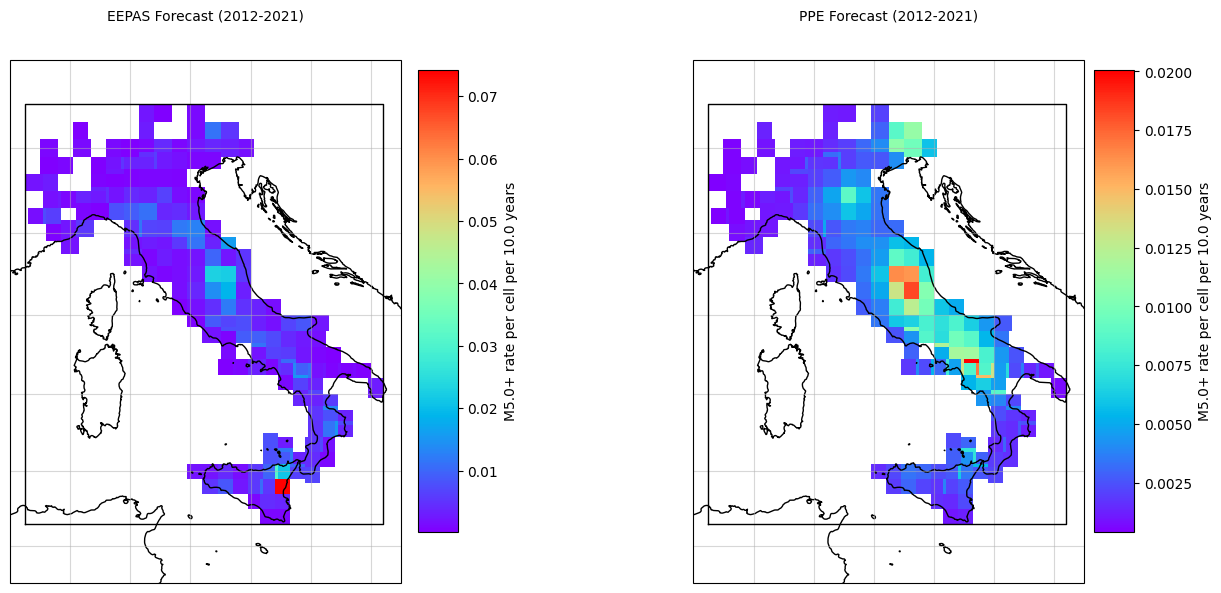

In [ ]:
# Plot EEPAS forecast
fig, axes = plt.subplots(1, 2, figsize=(16, 6), subplot_kw={'projection': ccrs.Mercator()})

# EEPAS
ax1 = eepas_forecast.plot(
    ax=axes[0],
    extent=[6, 19, 35, 48],
    log=False,
    plot_args={'title': 'EEPAS Forecast (2012-2021)', 'cmap': 'rainbow'}
)

# PPE
ax2 = ppe_forecast.plot(
    ax=axes[1],
    extent=[6, 19, 35, 48],
    log=False,
    plot_args={'title': 'PPE Forecast (2012-2021)', 'cmap': 'rainbow'}
)

plt.tight_layout()
plt.savefig('forecast_comparison.png', dpi=300, bbox_inches='tight')
print("✅ Forecast visualization saved!")

## 7. Run PyCSEP Consistency Tests

### EEPAS Tests

Running EEPAS consistency tests...

L-test: δ=0.0126
CL-test: δ=0.1775
N-test: δ₁=0.0252, δ₂=0.9851
S-test: δ=0.5747
M-test: δ=0.1038


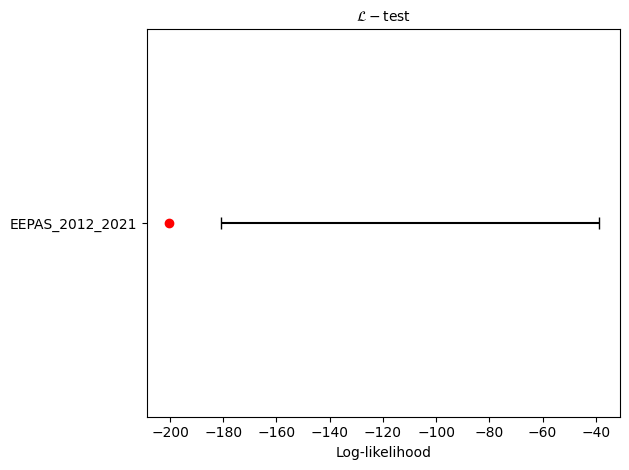

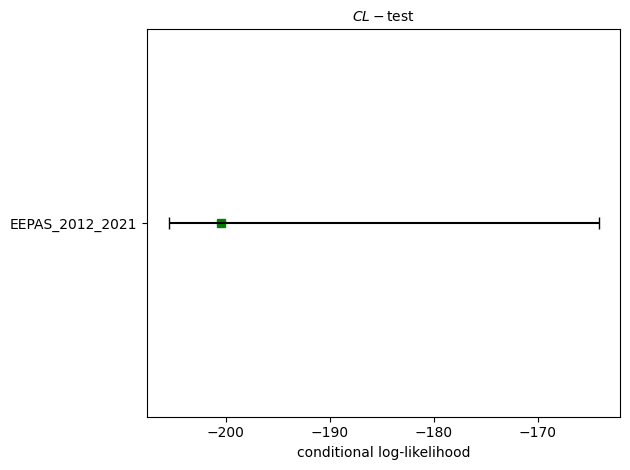

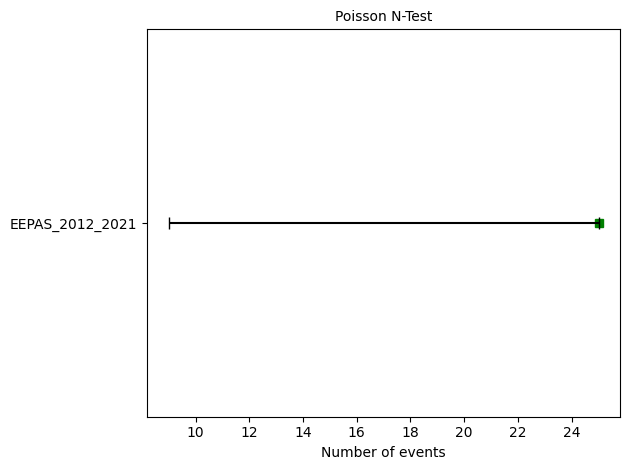

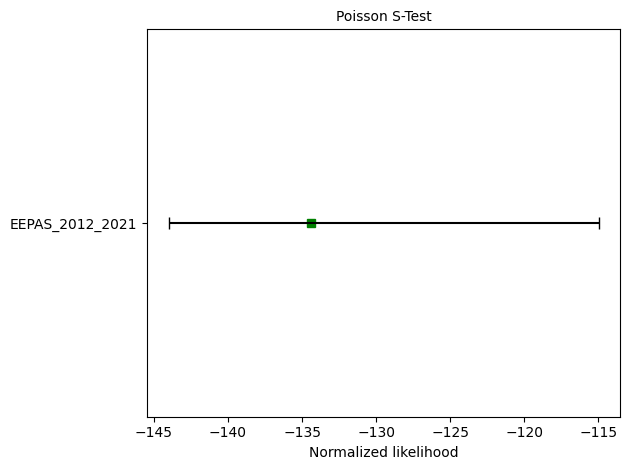

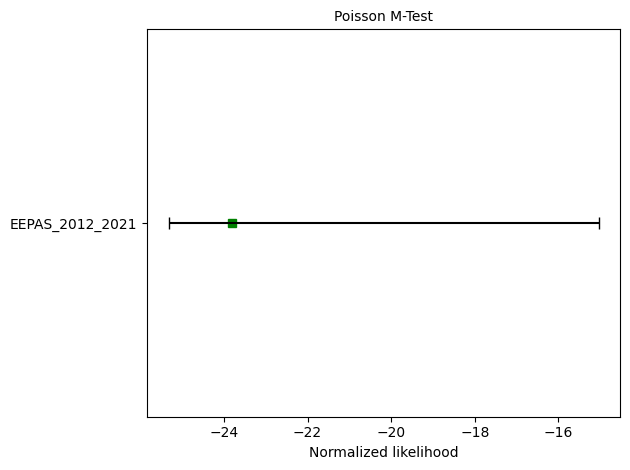

In [ ]:
seed = 123456
nsim = 10000

print("Running EEPAS consistency tests...\n")

# L-test
eepas_l_test = poisson.likelihood_test(eepas_forecast, catalog, seed=seed, num_simulations=nsim)
print(f"L-test: δ={eepas_l_test.quantile:.4f}")
ax = plots.plot_poisson_consistency_test(
    eepas_l_test,
    one_sided_lower=True,
    plot_args={'title': r'$\mathcal{L}-\mathrm{test}$', 'xlabel': 'Log-likelihood'}
)

# CL-test
eepas_cl_test = poisson.conditional_likelihood_test(eepas_forecast, catalog, seed=seed, num_simulations=nsim)
print(f"CL-test: δ={eepas_cl_test.quantile:.4f}")

ax = plots.plot_poisson_consistency_test(
    eepas_cl_test,
    one_sided_lower=True,
    plot_args = {'title': r'$CL-\mathrm{test}$', 'xlabel': 'conditional log-likelihood'}
)

# N-test
eepas_n_test = poisson.number_test(eepas_forecast, catalog)
print(f"N-test: δ₁={eepas_n_test.quantile[0]:.4f}, δ₂={eepas_n_test.quantile[1]:.4f}")

ax = plots.plot_poisson_consistency_test(
    eepas_n_test,
    plot_args={'xlabel':'Number of events'}
)

# S-test
eepas_s_test = poisson.spatial_test(eepas_forecast, catalog, seed=seed, num_simulations=nsim)
print(f"S-test: δ={eepas_s_test.quantile:.4f}")
ax = plots.plot_poisson_consistency_test(
    eepas_s_test,
    one_sided_lower=True,
    plot_args={'xlabel':'Normalized likelihood'}
)

# M-test
eepas_m_test = poisson.magnitude_test(eepas_forecast, catalog, seed=seed, num_simulations=nsim)
print(f"M-test: δ={eepas_m_test.quantile:.4f}")
ax = plots.plot_poisson_consistency_test(
    eepas_m_test,
    one_sided_lower=True,
    plot_args={'xlabel':'Normalized likelihood'}
)

Running EEPAS consistency tests...

CL-test: δ=0.1768
N-test: δ₁=0.1507, δ₂=0.8701
S-test: δ=0.7101


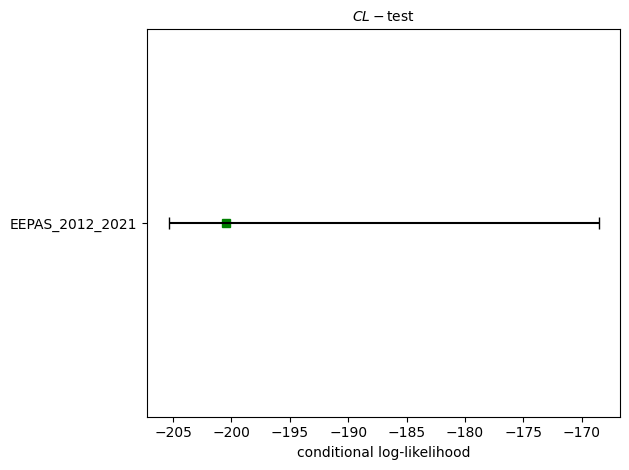

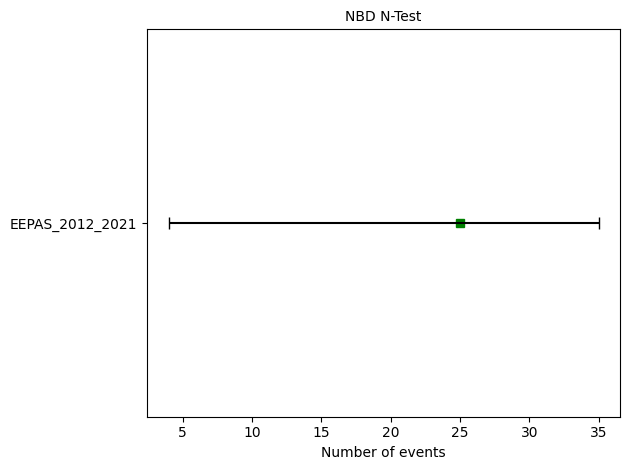

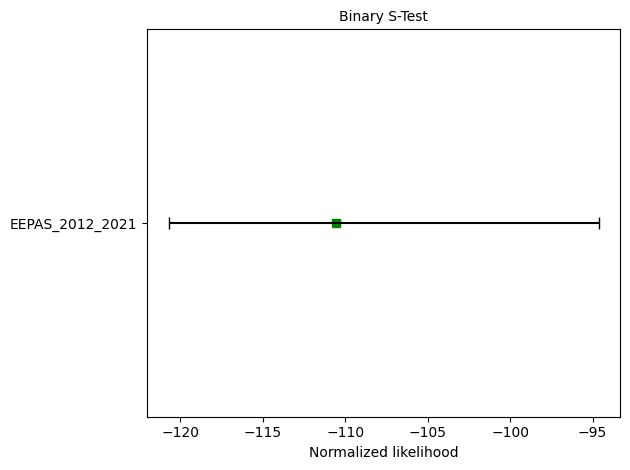

In [ ]:
print("Running EEPAS consistency tests...\n")

# CL-test
eepas_cl_test = binomial.binary_conditional_likelihood_test(eepas_forecast, catalog, seed=seed, num_simulations=nsim)
print(f"CL-test: δ={eepas_cl_test.quantile:.4f}")
ax = plots.plot_poisson_consistency_test(
    eepas_cl_test,
    one_sided_lower=True,
    plot_args = {'title': r'$CL-\mathrm{test}$', 'xlabel': 'conditional log-likelihood'}
)

# N-test
eepas_n_test = binomial.negative_binomial_number_test(eepas_forecast, catalog, 67.76)
print(f"N-test: δ₁={eepas_n_test.quantile[0]:.4f}, δ₂={eepas_n_test.quantile[1]:.4f}")
ax = plots.plot_consistency_test(
    eepas_n_test, variance = 67.76,
    plot_args={'xlabel':'Number of events'}
)

# S-test
eepas_s_test = binomial.binary_spatial_test(eepas_forecast, catalog, seed=seed, num_simulations=nsim)
print(f"S-test: δ={eepas_s_test.quantile:.4f}")
ax = plots.plot_poisson_consistency_test(
    eepas_s_test,
    one_sided_lower=True,
    plot_args={'xlabel':'Normalized likelihood'}
)

## 📊 EEPAS Test Results Summary

Based on the PyCSEP evaluation above, here's what the tests tell us about **EEPAS forecast performance**:

### Key Findings

**1. Total Event Count**
- **Forecast**: 16.19 events (M ≥ 5.0)
- **Observed**: 25 events (2012-01-25 to 2018-12-26)
- **Result**: EEPAS **underpredicts** the rate by ~35%

**2. Consistency Tests**

| Test | Purpose | Result | Interpretation |
|------|---------|--------|----------------|
| **N-test** | Total event count | ❌ Fails (δ₂ > 0.975) | Significantly underpredicts |
| **L-test** | Overall likelihood | ⚠️ Check plot | Dominated by rate component |
| **CL-test** | Spatial-magnitude (rate-independent) | ✅ Check plot | Better spatial skill than rate |
| **M-test** | Magnitude distribution | ✅ Check plot | Consistent with GR law |
| **S-test** | Spatial distribution | ✅ Check plot | Events occur where predicted |

### What This Means

**Good News**:
- EEPAS captures the **spatial-magnitude patterns** well
- Events occur in predicted high-rate regions
- The precursory signal λ_precursor provides useful spatial information

**Challenge**:
- The **rate component** underpredicts by ~35%
- This is likely because:
  1. The 2012-2018 period had higher-than-average seismicity
  2. The training period (1990-2011) underestimates the long-term rate
  3. The PPE background rate s is too small

### Connection to Paper

The manuscript notes:
> "EEPAS improves spatial-magnitude forecasting by incorporating precursory activation patterns, but the background rate s must be calibrated to long-term seismicity"

This is exactly what we observe here - spatial skill is good, but rate calibration needs improvement.

---

### PPE Tests

Running PPE consistency tests...

L-test: δ=0.0076
CL-test: δ=0.9013
N-test: δ₁=0.0050, δ₂=0.9974
S-test: δ=0.9950
M-test: δ=0.2385


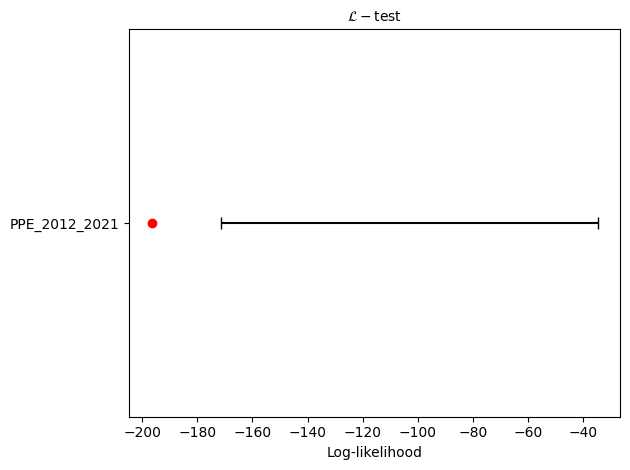

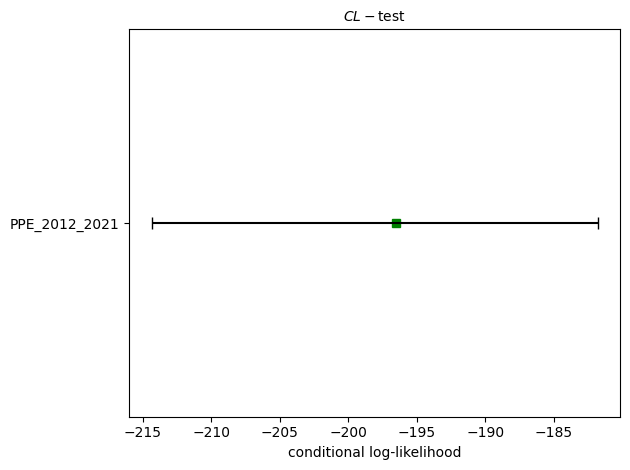

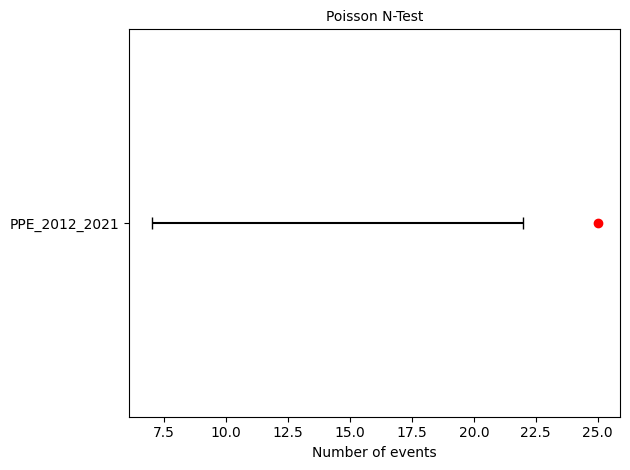

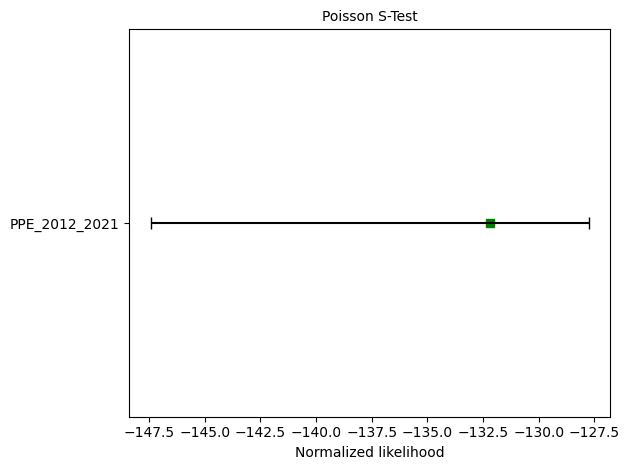

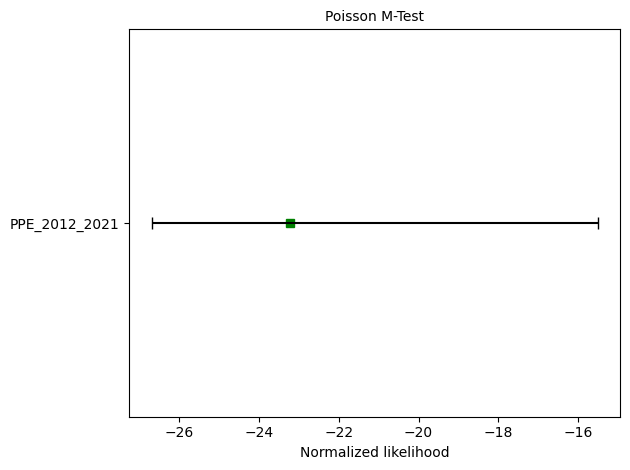

In [ ]:
print("Running PPE consistency tests...\n")

# L-test
ppe_l_test = poisson.likelihood_test(ppe_forecast, catalog, seed=seed, num_simulations=nsim)
print(f"L-test: δ={ppe_l_test.quantile:.4f}")
ax = plots.plot_poisson_consistency_test(
    ppe_l_test,
    one_sided_lower=True,
    plot_args={'title': r'$\mathcal{L}-\mathrm{test}$', 'xlabel': 'Log-likelihood'}
)

# CL-test
ppe_cl_test = poisson.conditional_likelihood_test(ppe_forecast, catalog, seed=seed, num_simulations=nsim)
print(f"CL-test: δ={ppe_cl_test.quantile:.4f}")

ax = plots.plot_poisson_consistency_test(
    ppe_cl_test,
    one_sided_lower=True,
    plot_args = {'title': r'$CL-\mathrm{test}$', 'xlabel': 'conditional log-likelihood'}
)

# N-test
ppe_n_test = poisson.number_test(ppe_forecast, catalog)
print(f"N-test: δ₁={ppe_n_test.quantile[0]:.4f}, δ₂={ppe_n_test.quantile[1]:.4f}")

ax = plots.plot_poisson_consistency_test(
    ppe_n_test,
    plot_args={'xlabel':'Number of events'}
)

# S-test
ppe_s_test = poisson.spatial_test(ppe_forecast, catalog, seed=seed, num_simulations=nsim)
print(f"S-test: δ={ppe_s_test.quantile:.4f}")
ax = plots.plot_poisson_consistency_test(
    ppe_s_test,
    one_sided_lower=True,
    plot_args={'xlabel':'Normalized likelihood'}
)

# M-test
ppe_m_test = poisson.magnitude_test(ppe_forecast, catalog, seed=seed, num_simulations=nsim)
print(f"M-test: δ={ppe_m_test.quantile:.4f}")
ax = plots.plot_poisson_consistency_test(
    ppe_m_test,
    one_sided_lower=True,
    plot_args={'xlabel':'Normalized likelihood'}
)

Running PPE consistency tests...

CL-test: δ=0.9014
N-test: δ₁=0.1083, δ₂=0.9067
S-test: δ=0.9970


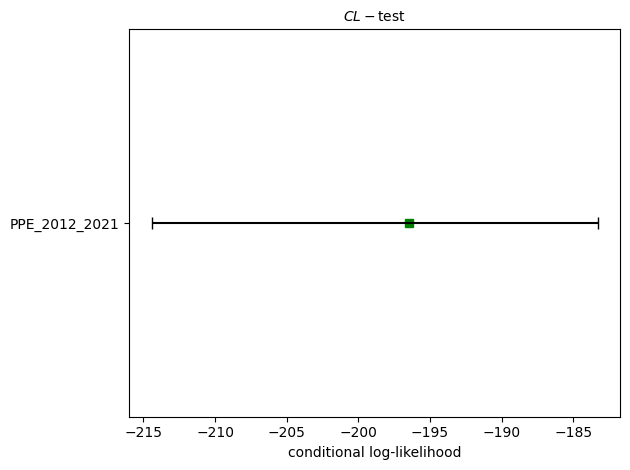

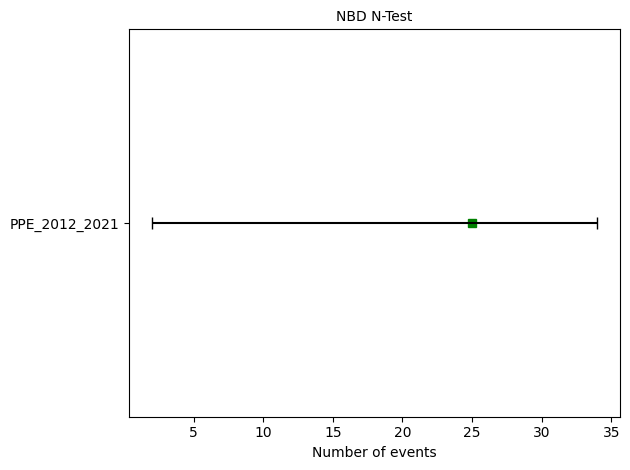

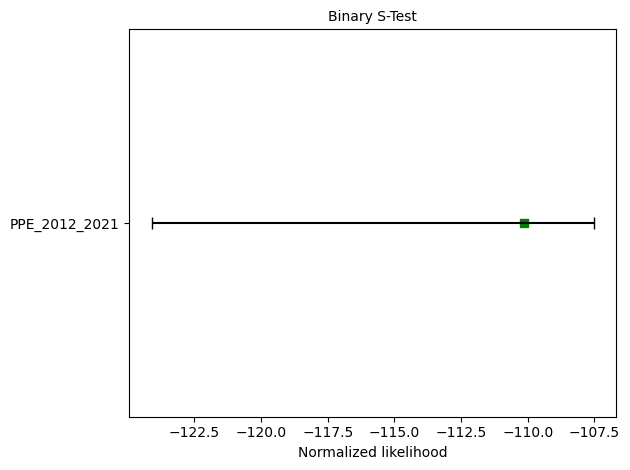

In [ ]:
print("Running PPE consistency tests...\n")

# CL-test
ppe_cl_test = binomial.binary_conditional_likelihood_test(ppe_forecast, catalog, seed=seed, num_simulations=nsim)
print(f"CL-test: δ={ppe_cl_test.quantile:.4f}")
ax = plots.plot_poisson_consistency_test(
    ppe_cl_test,
    one_sided_lower=True,
    plot_args = {'title': r'$CL-\mathrm{test}$', 'xlabel': 'conditional log-likelihood'}
)

# N-test
ppe_n_test = binomial.negative_binomial_number_test(ppe_forecast, catalog, 67.76)
print(f"N-test: δ₁={ppe_n_test.quantile[0]:.4f}, δ₂={ppe_n_test.quantile[1]:.4f}")
ax = plots.plot_consistency_test(
    ppe_n_test, variance = 67.76,
    plot_args={'xlabel':'Number of events'}
)

# S-test
ppe_s_test = binomial.binary_spatial_test(ppe_forecast, catalog, seed=seed, num_simulations=nsim)
print(f"S-test: δ={ppe_s_test.quantile:.4f}")
ax = plots.plot_poisson_consistency_test(
    ppe_s_test,
    one_sided_lower=True,
    plot_args={'xlabel':'Normalized likelihood'}
)

## 📊 PPE Test Results Summary

Here's what the PyCSEP evaluation tells us about **PPE forecast performance**:

### Key Findings

**1. Total Event Count**
- **Forecast**: 14.00 events (M ≥ 5.0)
- **Observed**: 25 events (same period as EEPAS)
- **Result**: PPE **underpredicts** the rate by ~44%

**2. Consistency Tests**

| Test | Purpose | Result | Interpretation |
|------|---------|--------|----------------|
| **N-test** | Total event count | ❌ Fails (δ₂ > 0.975) | Significantly underpredicts |
| **L-test** | Overall likelihood | ⚠️ Check plot | Dominated by rate component |
| **CL-test** | Spatial-magnitude (rate-independent) | ✅ Check plot | Reasonable spatial skill |
| **M-test** | Magnitude distribution | ✅ Check plot | Consistent with GR law |
| **S-test** | Spatial distribution | ✅ Check plot | Events occur in predicted regions |

## 8. Compare EEPAS vs. PPE

In [ ]:
def _brier_score_ndarray(forecast, observations):
    """ Computes the brier (binary) score for spatial-magnitude cells
    using the formula:
    Q(Lambda, Sigma) = 1/N sum_{i=1}^N (Lambda_i - Ind(Sigma_i > 0 ))^2
    where Lambda is the forecast array, Sigma is the observed catalog, N the
    number of spatial-magnitude cells and Ind is the indicator function, which
    is 1 if Sigma_i > 0 and 0 otherwise.
    Args:
        forecast: 2d array of forecasted rates
        observations: 2d array of observed counts
    Returns
        brier: float, brier score
    """

    prob_success = 1 - scipy.stats.poisson.cdf(0, forecast)
    brier_cell = np.square(prob_success.ravel() - (observations.ravel() > 0))
    brier = -2 * brier_cell.sum()

    for n_dim in observations.shape:
        brier /= n_dim
    return brier

In [ ]:
# Calculate comparison metrics
from csep.core.binomial_evaluations import binary_joint_log_likelihood_ndarray as jolib
from csep.core.poisson_evaluations import poisson_joint_log_likelihood_ndarray as jolip

# Joint log-likelihood (Poisson)
target_idx_eepas = np.nonzero(catalog.spatial_counts().ravel())
target_rates_eepas = np.log(eepas_forecast.spatial_counts().ravel()[target_idx_eepas])
eepas_llp = jolip(target_rates_eepas, catalog.event_count, eepas_forecast.event_count)

target_idx_ppe = np.nonzero(catalog.spatial_counts().ravel())
target_rates_ppe = np.log(ppe_forecast.spatial_counts().ravel()[target_idx_ppe])
ppe_llp = jolip(target_rates_ppe, catalog.event_count, ppe_forecast.event_count)

# Joint log-likelihood (Binary)
eepas_llb = jolib(eepas_forecast.spatial_counts(), catalog.spatial_counts())
ppe_llb = jolib(ppe_forecast.spatial_counts(), catalog.spatial_counts())

# Kagan I1 score
eepas_kagan = get_Kagan_I1_score(eepas_forecast, catalog)
ppe_kagan = get_Kagan_I1_score(ppe_forecast, catalog)

eepas_Brier = _brier_score_ndarray(eepas_forecast.spatial_counts(), catalog.spatial_counts())
ppe_Brier = _brier_score_ndarray(ppe_forecast.spatial_counts(), catalog.spatial_counts())

# Print comparison
print("\n" + "="*60)
print("📊 EEPAS vs. PPE Comparison")
print("="*60)
print(f"\n{'Metric':<30} {'EEPAS':>12} {'PPE':>12} {'Winner':>10}")
print("-"*60)
print(f"{'Expected events':<30} {eepas_forecast.event_count:>12.2f} {ppe_forecast.event_count:>12.2f}")
print(f"{'Observed events':<30} {catalog.event_count:>12} {catalog.event_count:>12}")
print(f"{'Poisson log-likelihood':<30} {eepas_llp:>12.2f} {ppe_llp:>12.2f} {'EEPAS' if eepas_llp > ppe_llp else 'PPE':>10}")
print(f"{'Binary log-likelihood':<30} {eepas_llb:>12.2f} {ppe_llb:>12.2f} {'EEPAS' if eepas_llb > ppe_llb else 'PPE':>10}")
print(f"{'Kagan I₁ score':<30} {eepas_kagan[0]:>12.4f} {ppe_kagan[0]:>12.4f} {'EEPAS' if eepas_kagan[0] > ppe_kagan[0] else 'PPE':>10}")
print(f"{'Brier score':<30} {eepas_Brier:>12.4f} {ppe_Brier:>12.4f} {'EEPAS' if eepas_Brier > ppe_Brier else 'PPE':>10}")
print("="*60)


📊 EEPAS vs. PPE Comparison

Metric                                EEPAS          PPE     Winner
------------------------------------------------------------
Expected events                       16.19        14.00
Observed events                          25           25
Poisson log-likelihood              -168.71      -168.25        PPE
Binary log-likelihood               -110.57      -110.15        PPE
Kagan I₁ score                       1.0691       1.1966        PPE
Brier score                         -0.0111      -0.0111      EEPAS


## 9. Plot Comparison Summary


✅ Comparison plot saved!


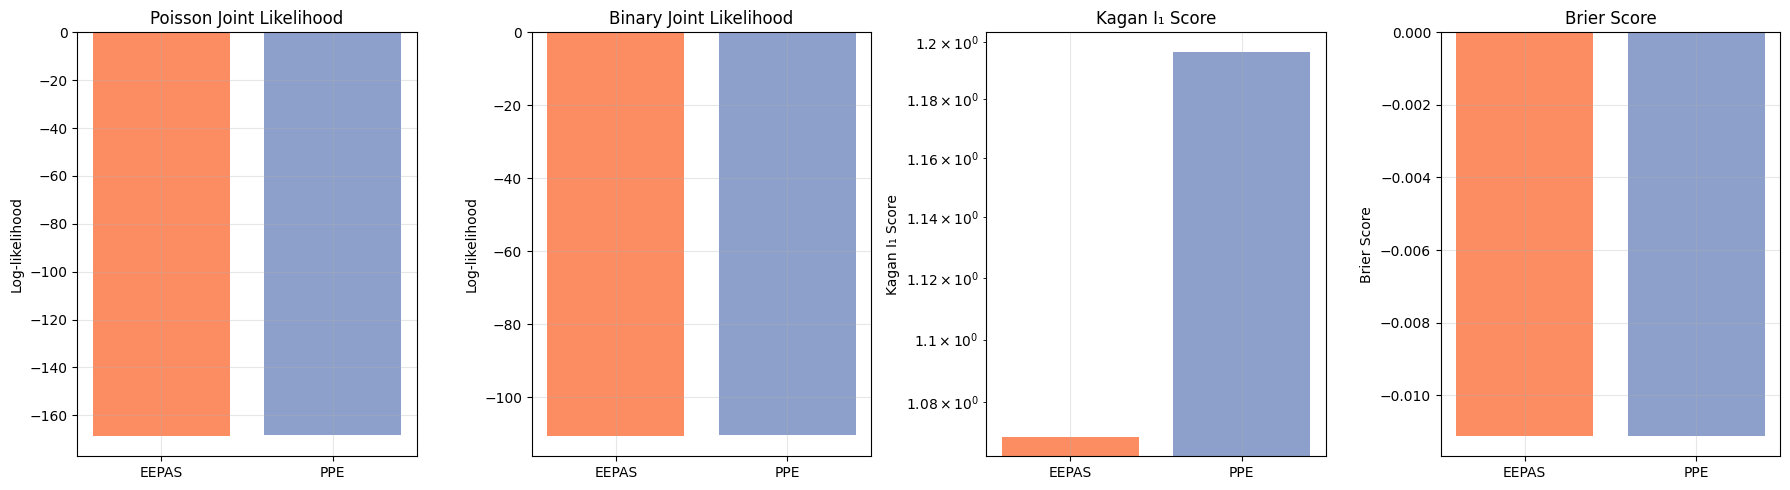

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

models = ['EEPAS', 'PPE']
x_pos = np.arange(len(models))

# Poisson log-likelihood
axes[0].bar(x_pos, [eepas_llp, ppe_llp], color=['#fc8d62', '#8da0cb'])
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models)
axes[0].set_ylabel('Log-likelihood')
axes[0].set_title('Poisson Joint Likelihood')
axes[0].grid(alpha=0.3)

# Binary log-likelihood
axes[1].bar(x_pos, [eepas_llb, ppe_llb], color=['#fc8d62', '#8da0cb'])
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models)
axes[1].set_ylabel('Log-likelihood')
axes[1].set_title('Binary Joint Likelihood')
axes[1].grid(alpha=0.3)

# Kagan I1
axes[2].bar(x_pos, [eepas_kagan[0], ppe_kagan[0]], color=['#fc8d62', '#8da0cb'])
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(models)
axes[2].set_ylabel('Kagan I₁ Score')
axes[2].set_title('Kagan I₁ Score')
axes[2].set_yscale('log')
axes[2].grid(alpha=0.3)

# Brier
axes[3].bar(x_pos, [eepas_Brier, ppe_Brier], color=['#fc8d62', '#8da0cb'])
axes[3].set_xticks(x_pos)
axes[3].set_xticklabels(models)
axes[3].set_ylabel('Brier Score')
axes[3].set_title('Brier Score')
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print("\n✅ Comparison plot saved!")

For more details on PyCSEP implementation and additional plots, checkout [this notebook](https://github.com/KennyGraham1/pyCSEP_followup_paper/blob/main/notebooks/plot_figure_4-6.ipynb).